# Import config file which stores all hyperparameter values

In [1]:
import os 
import configparser

In [2]:
config_path = "configs/Training_config2.ini"
config_read = configparser.ConfigParser()
config_read.read(config_path)

['configs/Training_config2.ini']

In [3]:
for sect in config_read.sections():
    print('Title:', sect)
    for k,v in config_read.items(sect):
        print(' {} = {}'.format(k,v))
    print()

Title: TrainingInfo
 traindataset = ['jaadall_with_c_g/train/']
 loss = BCE
 save_model_folder_acc = training_results/best_val_acc/
 save_model_folder_f1 = training_results/best_val_f1/
 batch_size = 500
 stratifiedkfold_random_state = 1
 graph_seed = 2676
 1dcnn_seed = 2726



In [4]:
import json
train_folder = json.loads(config_read.get("TrainingInfo", "traindataset").replace("'",'"'))
loss_name = config_read.get("TrainingInfo", "loss")
save_model_folder_acc = config_read.get("TrainingInfo", "save_model_folder_acc")
save_model_folder_f1 = config_read.get("TrainingInfo", "save_model_folder_f1")
batch_size = int(config_read.get("TrainingInfo", "batch_size"))
ran_2 = int(config_read.get("TrainingInfo", "stratifiedkfold_random_state"))

In [5]:
train_folder

['jaadall_with_c_g/train/']

# Load training data 

In [6]:
import os

In [7]:
import numpy as np


In [8]:
root = 'preprocessed_data/'+train_folder[0]
x_c_train, x_g_train, y_c_train = np.load(root + 'x_c.npy'), np.load(root + 'x_g.npy'), np.load(root + 'y.npy')


In [9]:
print(x_c_train.shape, x_g_train.shape, y_c_train.shape)#categorical, global categorical, gt

(162254, 16, 2) (162254, 2) (162254, 1)


In [10]:
def count_imbalance(y_t):
    count_pos, count_neg = 0, 0
    for label in y_t:
        if label == [1.0]:
            count_pos+=1
        else:
            count_neg+=1
    if count_pos>count_neg:
        print('Negative class is minority class')
    else:
        print('Positive class is minority class')
        
    print('Imbalance ratio: {0}:{1}'.format(str(round(count_pos/len(y_t),2)), str(round(count_neg/len(y_t),2))))
    print('Number of sample deficit: {0}'.format(str(abs(count_pos-count_neg))))
    return count_pos/(count_pos+count_neg)

In [11]:
alpha = count_imbalance(y_c_train)

Positive class is minority class
Imbalance ratio: 0.09:0.91
Number of sample deficit: 133776


# Sample without replacement to majority class

In [12]:
import random
pool = [i for i in range(1, 11)]
indices = range(len(pool))

In [13]:
a = random.sample(pool, 5)
print(a)

[8, 6, 2, 4, 1]


In [14]:
# idea: each fold have a full set of positive samples + random selected negative samples whose number the same as pos
# idea2: each fold's negative samples are sampled without replacement, meaning they won't repeated in other folds
# idea3: fix the seed to make result reproducible 

In [15]:
x_c_train.shape, x_g_train.shape, y_c_train.shape

((162254, 16, 2), (162254, 2), (162254, 1))

In [16]:
pos_indices = np.squeeze(y_c_train==1)
neg_indices = np.squeeze(y_c_train==0)

In [17]:
# split pos/neg
x_c_pos_train = x_c_train[pos_indices]
x_g_pos_train = x_g_train[pos_indices]
y_c_pos_train = y_c_train[pos_indices]

x_c_neg_train = x_c_train[neg_indices]
x_g_neg_train = x_g_train[neg_indices]
y_c_neg_train = y_c_train[neg_indices]

x_shuffle_neg_indices = [i for i in range(len(y_c_neg_train))]
np.random.seed(10)
np.random.shuffle(x_shuffle_neg_indices)

In [18]:
# np.random.seed(10)
# np.random.shuffle(x_shuffle_neg_indices)
random.seed(38)
shuffle_indices = random.sample(x_shuffle_neg_indices, len(y_c_pos_train)*5)


In [19]:
pos_num = len(y_c_pos_train)
folds = 5
for i in range(folds):
    neg_fold_indices = [i*pos_num, i*pos_num+pos_num]
#     print(neg_fold_indices)

In [20]:
neg_fold_indices

[56956, 71195]

# Prepare a training function

In [21]:
import os
import torch 
import numpy as np
import utils.data_loader as Dataset
from torch.utils.data import DataLoader
import models.stacked_gru_16frames as ModGRU
import pandas as pd

In [23]:
pos_num = len(y_c_pos_train)

x1_data_sizes = [(16, 1), (16, 1)] 
x2_data_size = x_g_train.shape

print(x2_data_size)

(162254, 2)


Fold 1:
Dataloader seed: 2726
[INFO]: Epoch 2 of 100


/data/home/acw607/stacking/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training loss: 0.668, training acc: 50.000
Validation loss: 0.662, validation acc: 50.000
--------------------------------------------------

Best validation acc: 50.0

Saving best model for epoch: 2


Best validation f1: 0.33

Saving best model for epoch: 2

[INFO]: Epoch 3 of 100


/data/home/acw607/stacking/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/data/home/acw607/stacking/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Training loss: 0.661, training acc: 50.000
Validation loss: 0.660, validation acc: 50.000
--------------------------------------------------
[INFO]: Epoch 4 of 100
Training loss: 0.659, training acc: 50.000
Validation loss: 0.656, validation acc: 50.000
--------------------------------------------------
[INFO]: Epoch 5 of 100
Training loss: 0.653, training acc: 52.000
Validation loss: 0.645, validation acc: 61.000
--------------------------------------------------

Best validation acc: 61.0

Saving best model for epoch: 5


Best validation f1: 0.6

Saving best model for epoch: 5

[INFO]: Epoch 6 of 100
Training loss: 0.642, training acc: 56.000
Validation loss: 0.630, validation acc: 61.000
--------------------------------------------------
[INFO]: Epoch 7 of 100
Training loss: 0.627, training acc: 62.000
Validation loss: 0.623, validation acc: 61.000
--------------------------------------------------

Best validation f1: 0.61

Saving best model for epoch: 7

[INFO]: Epoch 8 of 100
Tra

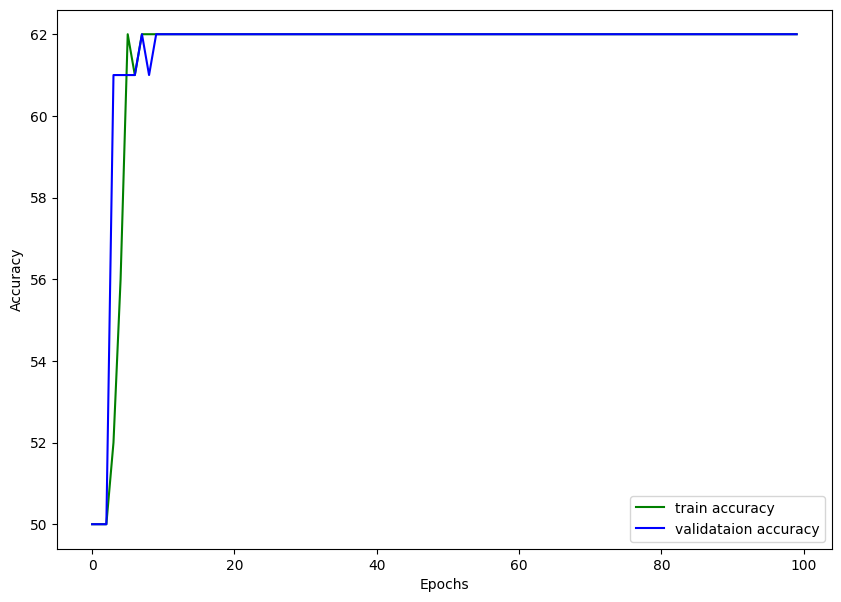

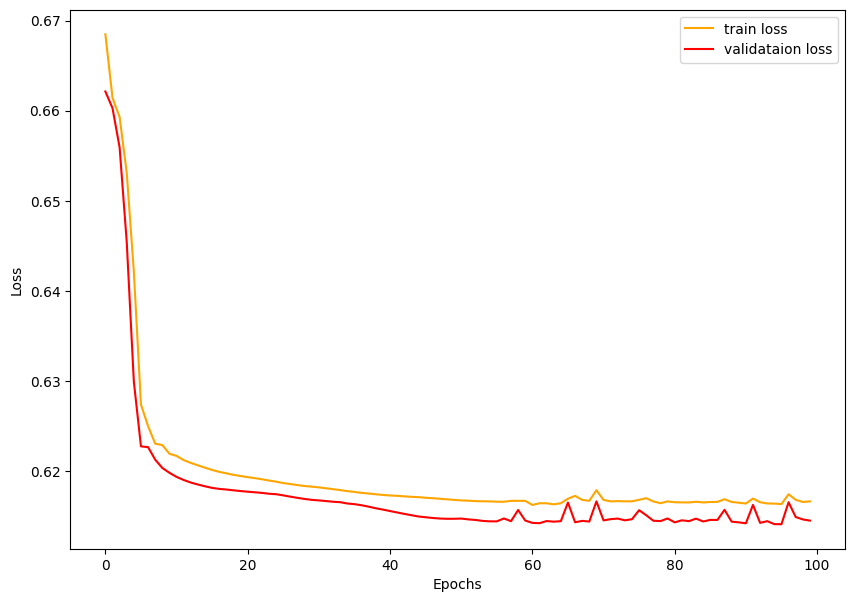

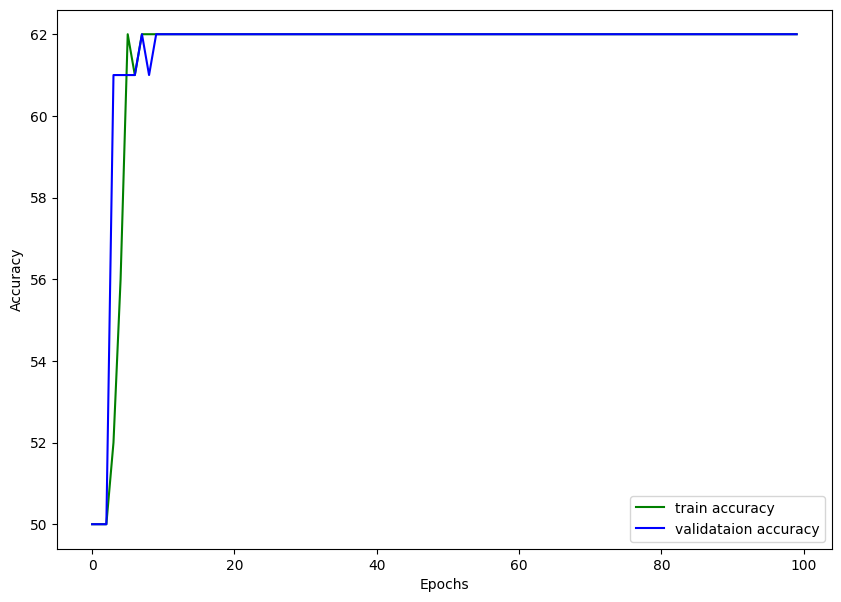

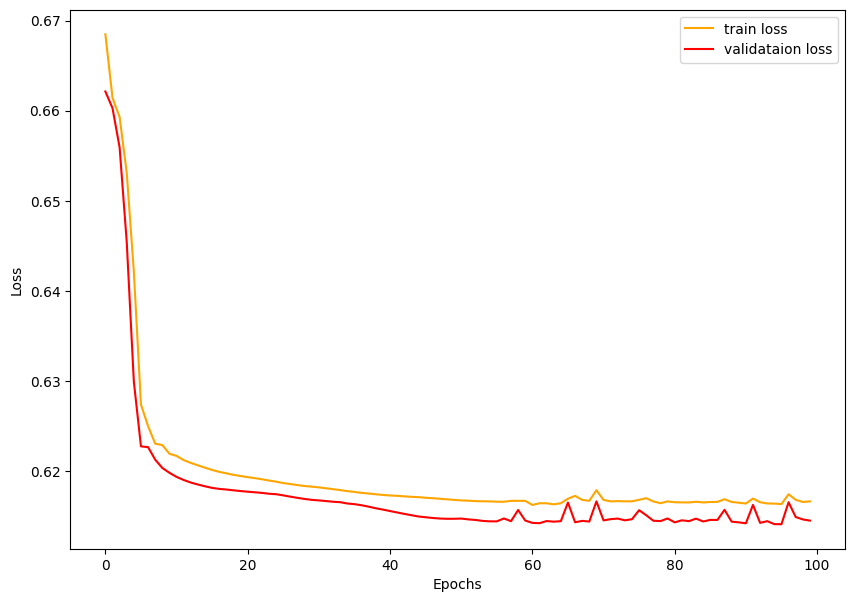

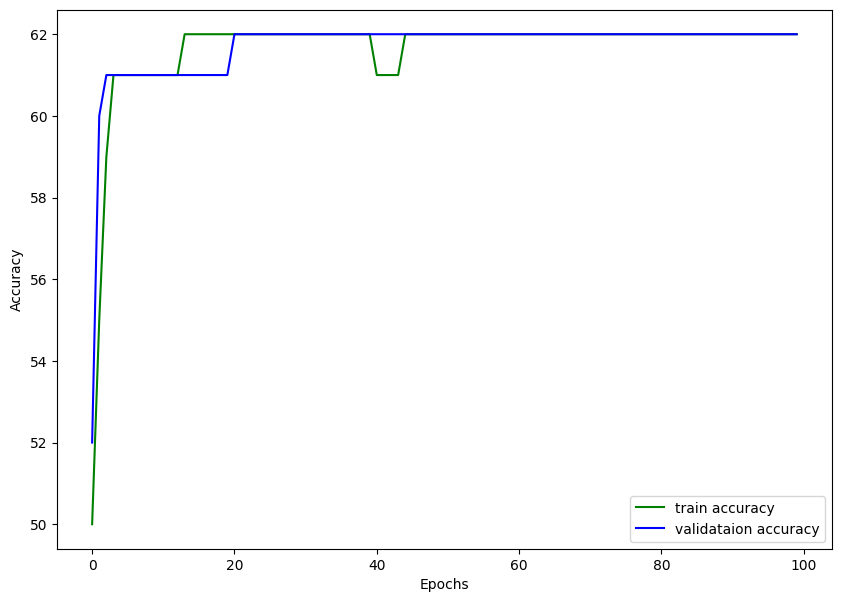

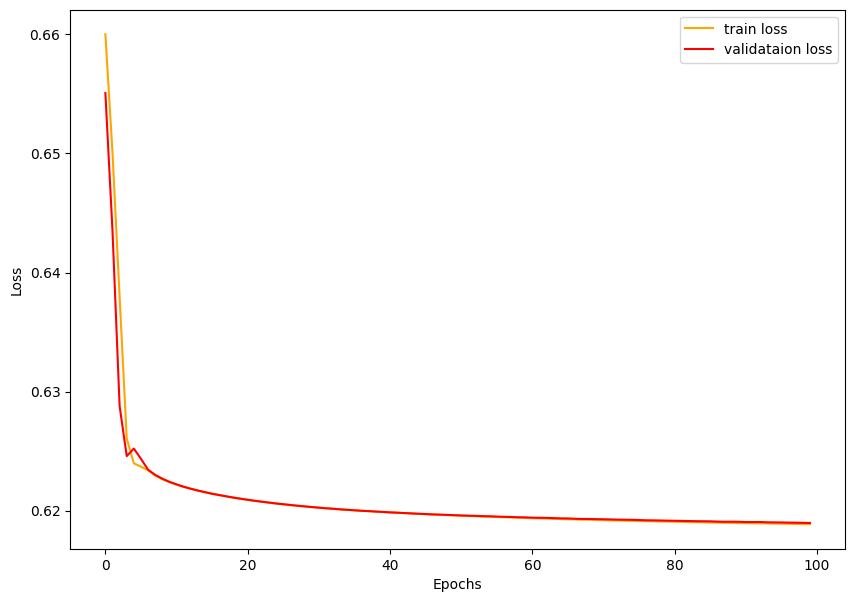

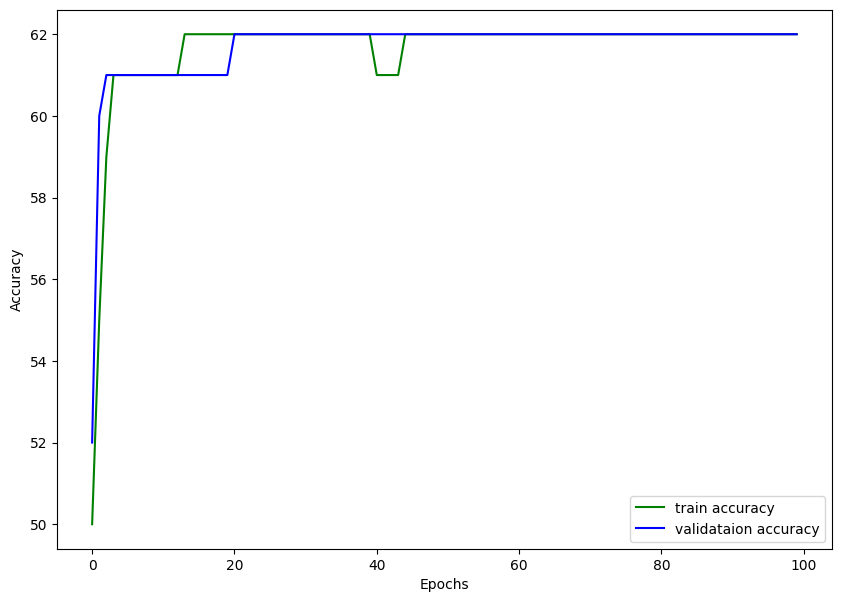

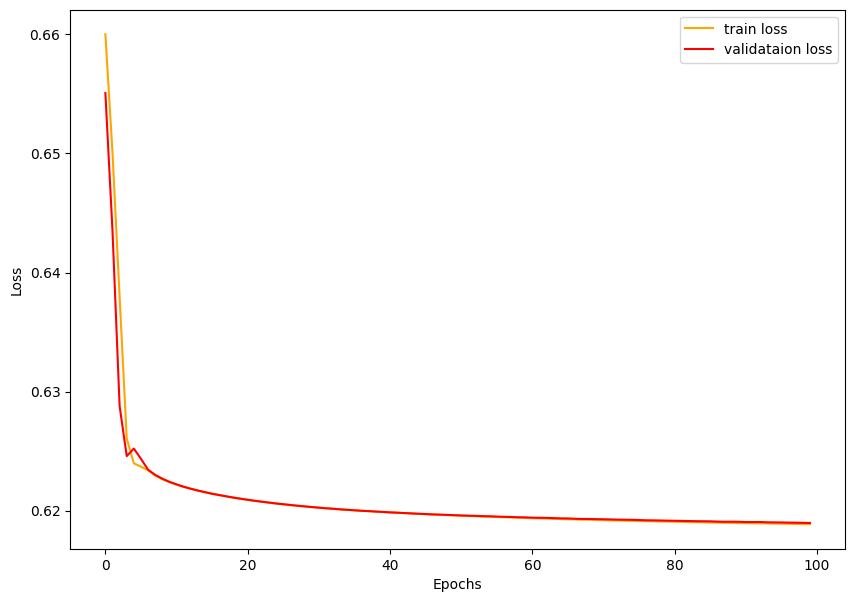

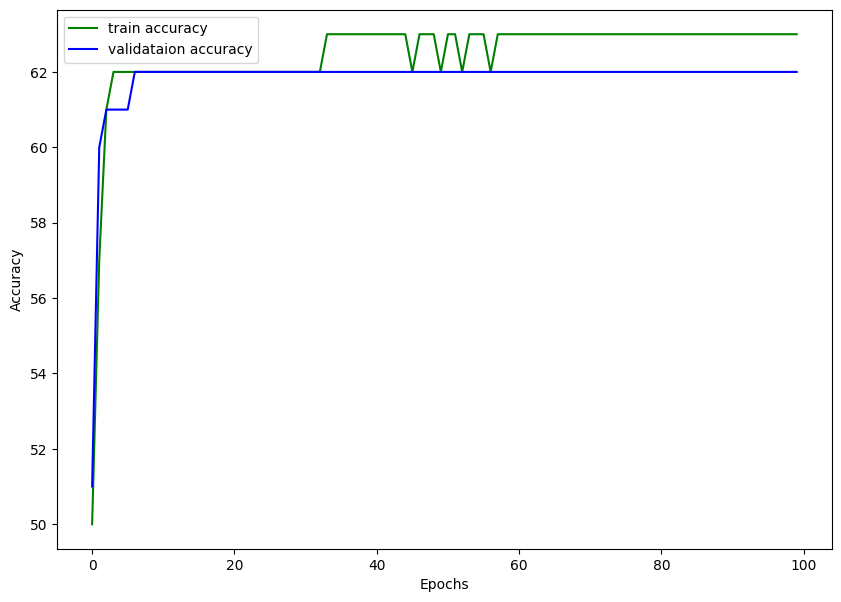

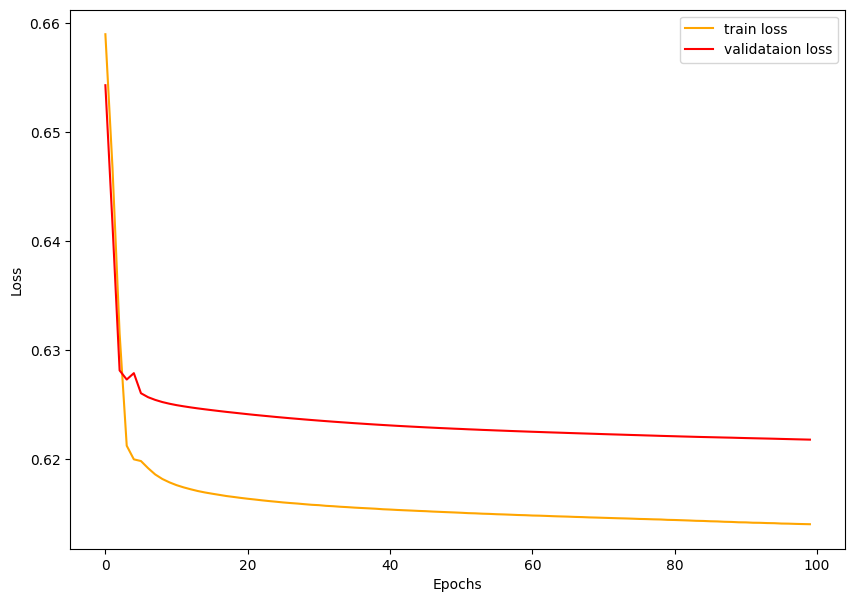

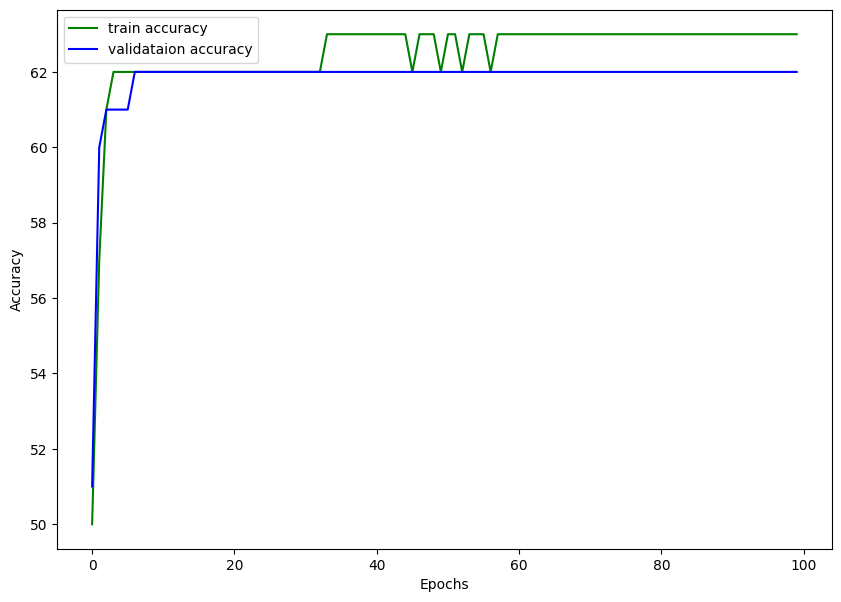

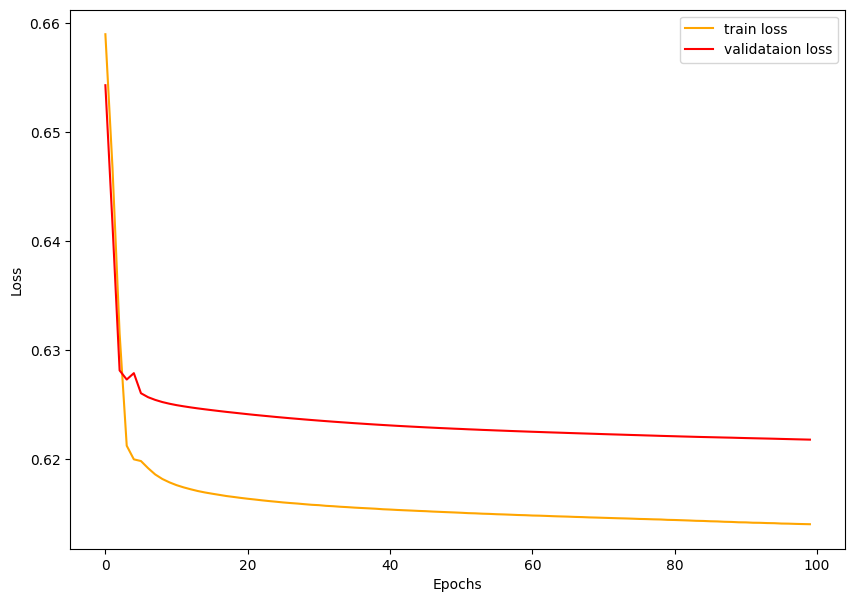

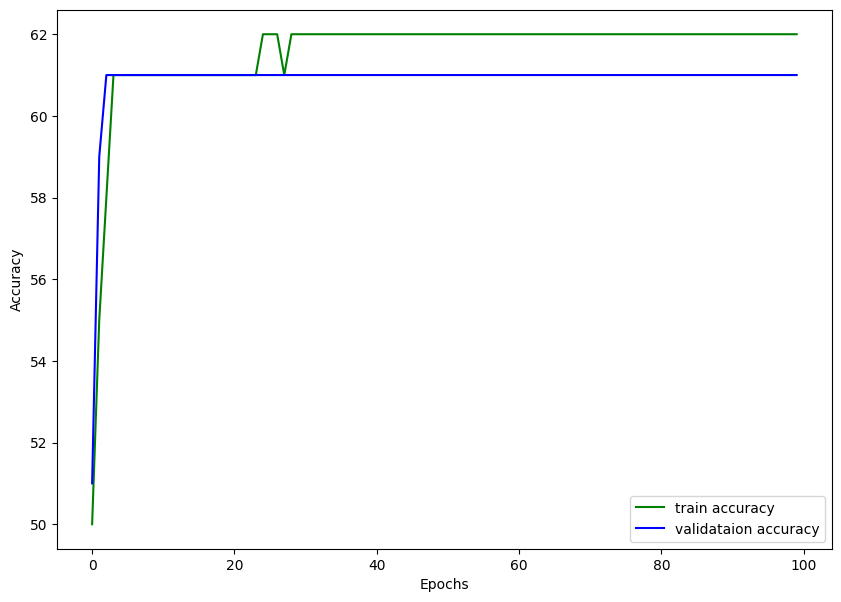

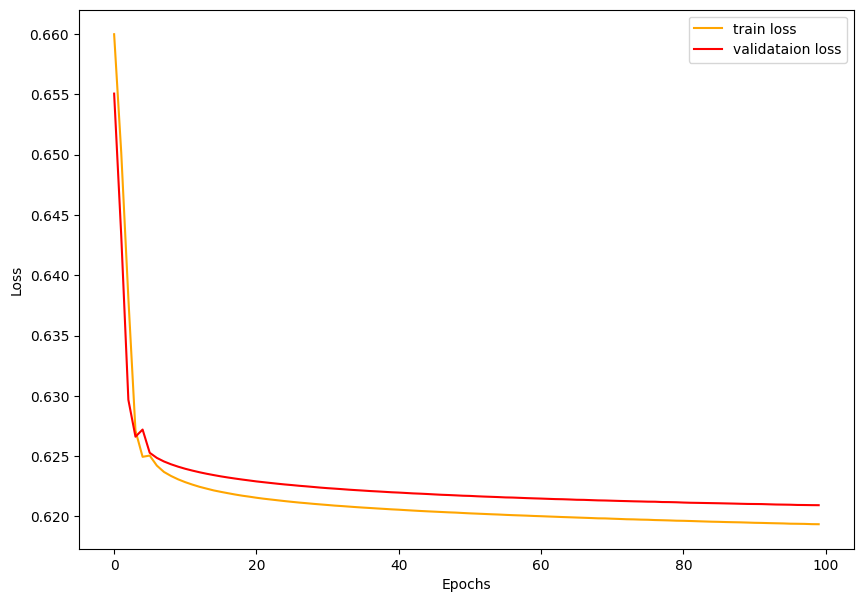

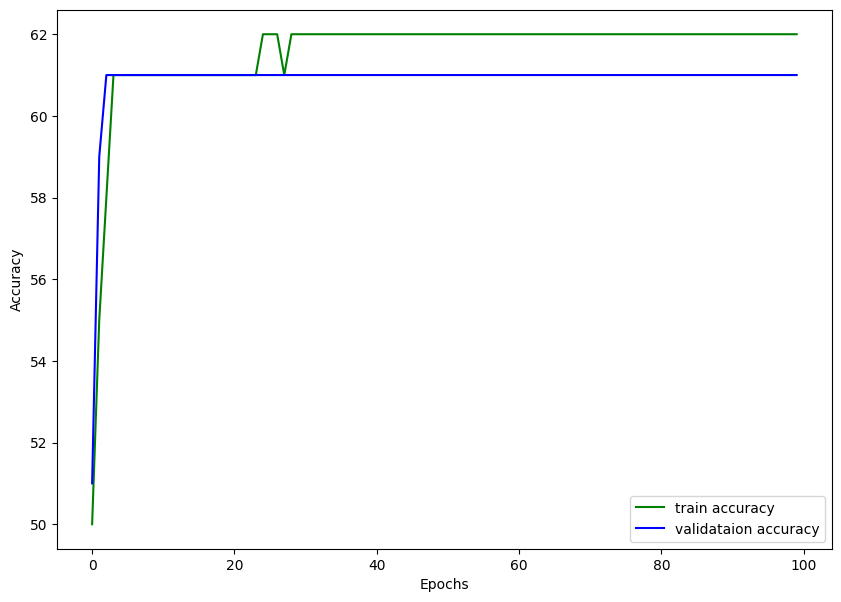

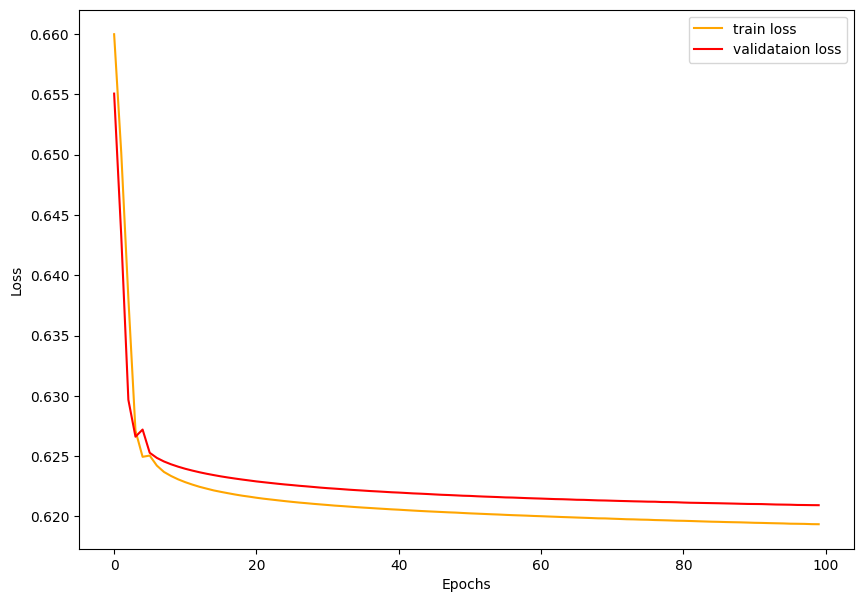

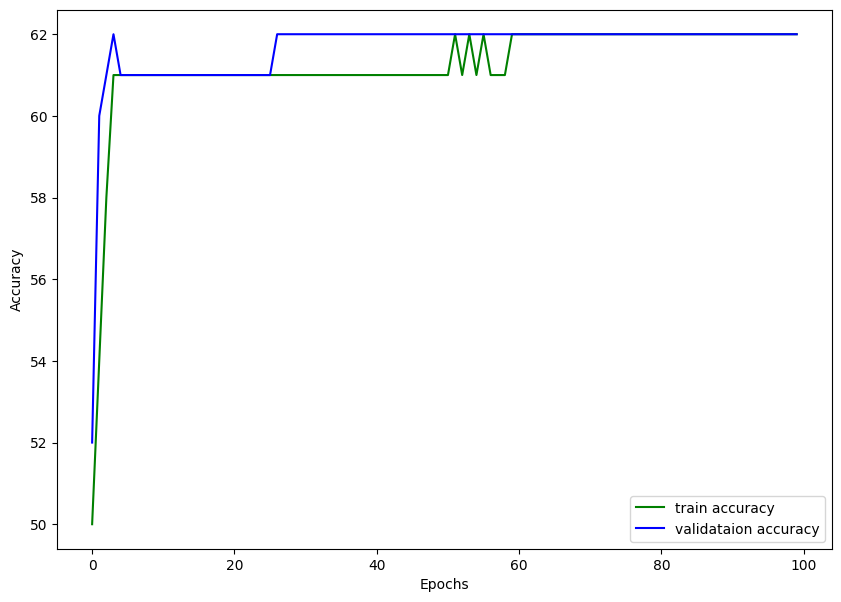

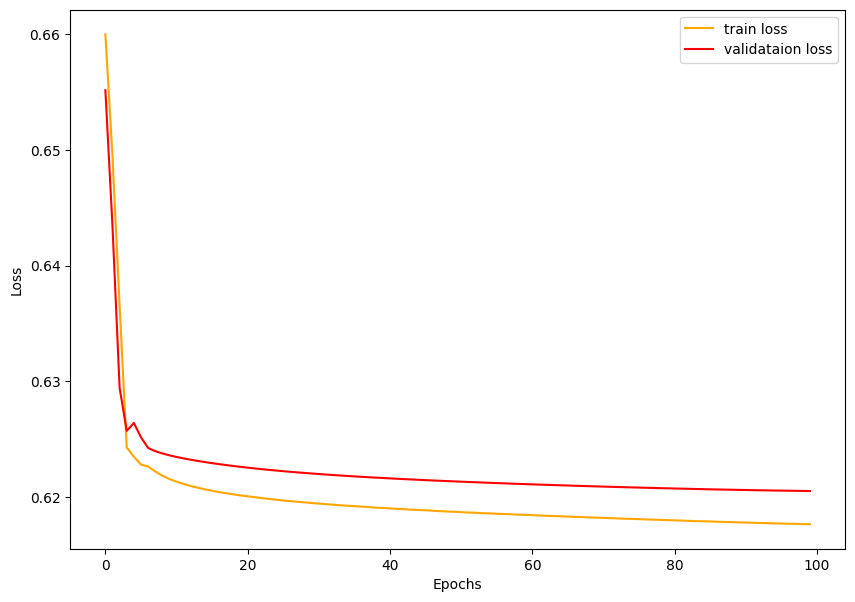

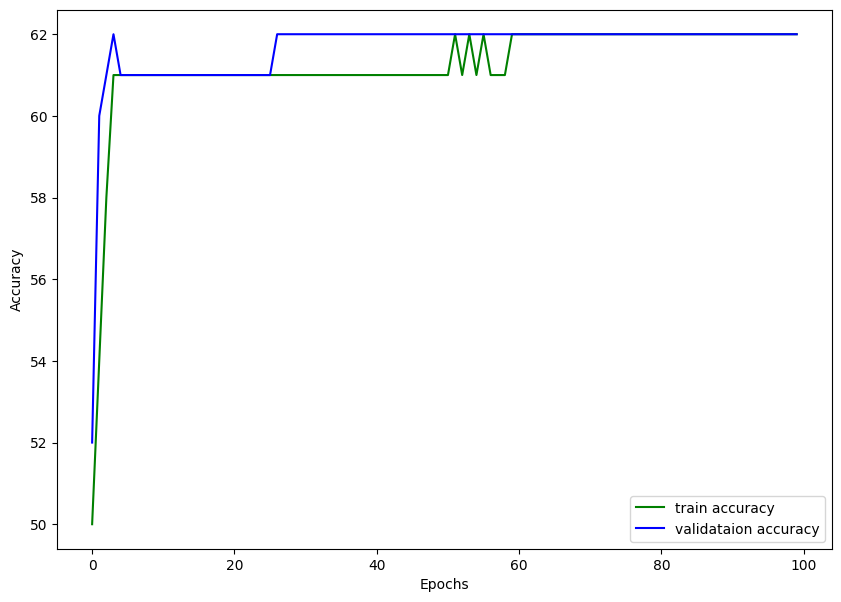

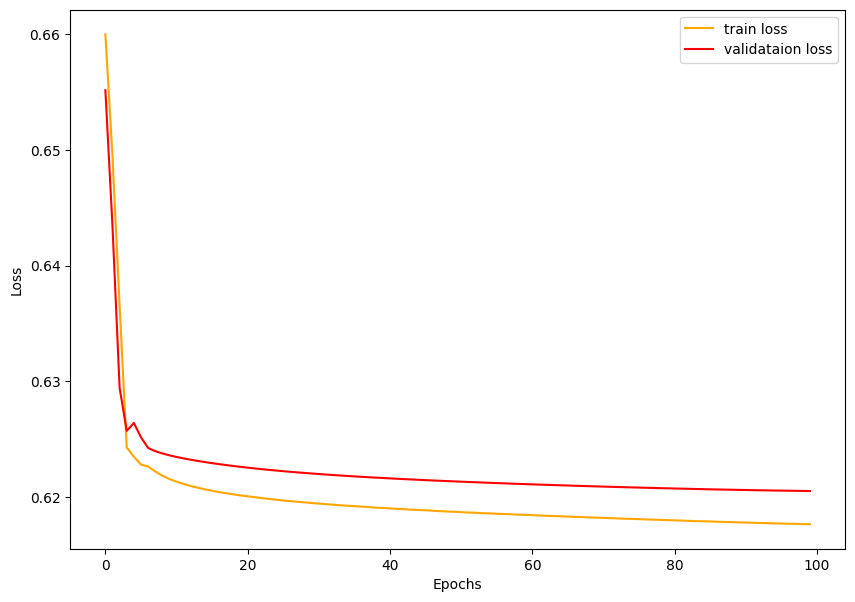

In [23]:
from sklearn.model_selection import train_test_split

pos_num = len(y_c_pos_train)

x1_data_sizes = [(16, 1), (16, 1)] 
x2_data_size = x_g_train.shape

for i in range(folds):

    print(f"Fold {i+1}:")
    save_fold_folder_acc = save_model_folder_acc+'fold_{0}/'.format(str(i+1))
    save_fold_folder_f1 = save_model_folder_f1+'fold_{0}/'.format(str(i+1))

    neg_fold_idx = [i*pos_num, i*pos_num+pos_num]
    neg_idx_start, neg_idx_end = neg_fold_idx[0], neg_fold_idx[1]
    sampled_indices = shuffle_indices[neg_idx_start:neg_idx_end]

    x_c_neg_samples = x_c_neg_train[sampled_indices]
    x_g_neg_samples = x_g_neg_train[sampled_indices]
    y_c_neg_samples = y_c_neg_train[sampled_indices]


    merge_c = np.concatenate([x_c_pos_train, x_c_neg_samples])
    merge_g = np.concatenate([x_g_pos_train, x_g_neg_samples])
    merge_y = np.concatenate([y_c_pos_train, y_c_neg_samples])

    x1_train, x1_val, y1_train, y1_val = train_test_split(merge_c, merge_y, test_size=0.20, random_state=42)
    x2_train, x2_val, y2_train, y2_val = train_test_split(merge_g, merge_y, test_size=0.20, random_state=42)

    if np.array_equal(y1_train, y2_train) and np.array_equal(y1_val, y2_val):
        x1_train = torch.FloatTensor(x1_train)
        x2_train = torch.FloatTensor(x2_train)
        y_train = torch.FloatTensor(y1_train)

        x1_val = torch.FloatTensor(x1_val)
        x2_val = torch.FloatTensor(x2_val)
        y_val = torch.FloatTensor(y1_val)

        train_data = Dataset.CategoricalData(x1_train, x2_train, y_train)
        val_data = Dataset.CategoricalData(x1_val, x2_val, y_val)

        train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True,drop_last=True)
        val_loader = DataLoader(dataset=val_data, batch_size=batch_size, drop_last=True)    

        ModGRU.train_stacked_gru(x1_data_sizes, x2_data_size, train_loader, val_loader, save_fold_folder_acc, save_fold_folder_f1, loss_name, alpha)


#     x1_train = torch.FloatTensor(x_c_train)[train_index]
#     x2_train = torch.FloatTensor(x_g_train)[train_index]
#     y_train = torch.FloatTensor(y_c_train)[train_index]

#     x1_val = torch.FloatTensor(x_c_train)[val_index]
#     x2_val = torch.FloatTensor(x_g_train)[val_index]
#     y_val = torch.FloatTensor(y_c_train)[val_index]